In [1]:
dir =  "/media/adaptation/New_volume/Domain_Adaptation_Pipeline/ColomboHM3D/ReplicaDataset/apartment0/"
dir_input = "RGB"
dirs_out = ["deeplab", "deeplab_colored"]

In [2]:
from helper.resources import NYU40_MAPPING_FILE
import numpy as np

def rgb_to_class_index(rgb_image, tolerance=5):

    mapping = np.genfromtxt(NYU40_MAPPING_FILE, delimiter=",")[1:, 1:4]

    h, w = rgb_image.shape[:2]
    class_map = np.zeros((h, w), dtype=np.int32)
    for class_idx, color in enumerate(mapping):
        mask = np.all(np.abs(rgb_image - color) <= tolerance, axis=-1)
        class_map[mask] = class_idx
    return class_map

In [45]:
from PIL import Image
import numpy as np
import cv2

path = dir  + "GT/64.png"

pred_img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
pred_img = cv2.resize(pred_img, (320,240), interpolation=cv2.INTER_NEAREST)

print(pred_img.max())
pred_img[200, 0]

40


3

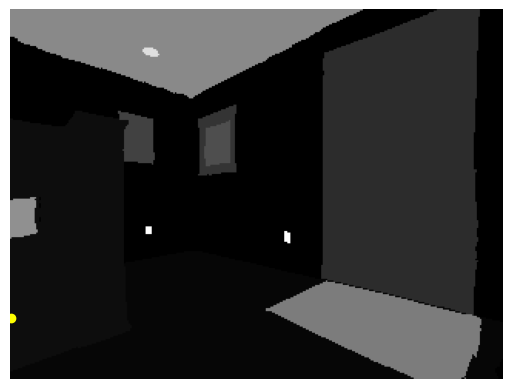

In [37]:
import matplotlib.pyplot as plt
import numpy as np



# Se hai già un array numpy (H,W) o (H,W,3)
plt.imshow(pred_img, cmap="gray")   # usa cmap="gray" se è una maschera

plt.scatter(0, 200, c='yellow', marker='o')
plt.axis("off")  # toglie gli assi
plt.show()

In [46]:
path = dir  + "deeplab/64.png"


pred_img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
arr = np.array(pred_img)
pred_img = arr
print(arr.max())
pred_img[200, 0]

38


38

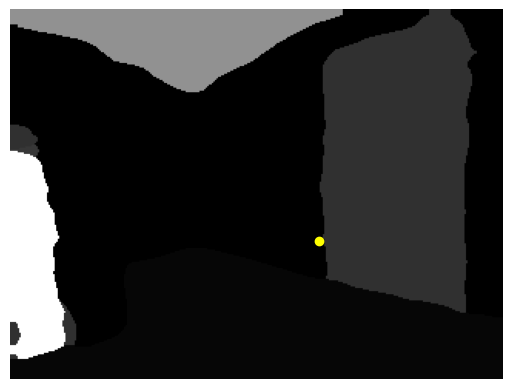

In [39]:

# Se hai già un array numpy (H,W) o (H,W,3)
plt.imshow(pred_img, cmap="gray")   # usa cmap="gray" se è una maschera

plt.scatter(200, 150, c='yellow', marker='o')
plt.axis("off")  # toglie gli assi
plt.show()

In [54]:
from metrics.SemanticMeter import SemanticsMeter

path = dir  + "GT/64.png"
path1 = dir  + "deeplab/64.png"

meter = SemanticsMeter(number_classes=40)

meter.clear()

gt_img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
gt_img = cv2.resize(gt_img, (320,240), interpolation=cv2.INTER_NEAREST)
arr1 = gt_img.astype(np.int16) - 1

pred_img = cv2.imread(path1, cv2.IMREAD_UNCHANGED)
arr2 = pred_img.astype(np.int16) - 1

meter.update(arr2, arr1)
miou, acc, class_acc = meter.measure()
miou

/media/adaptation/New_volume/Domain_Adaptation_Pipeline/domain.adaptation.3D/catkin_ws/src/Modules/metrics/SemanticMeter.py:50: RuntimeWarning: invalid value encountered in divide
  norm_conf_mat = np.transpose(np.transpose(conf_mat) / conf_mat.astype(np.float64).sum(axis=1))
/media/adaptation/New_volume/Domain_Adaptation_Pipeline/domain.adaptation.3D/catkin_ws/src/Modules/metrics/SemanticMeter.py:60: RuntimeWarning: invalid value encountered in scalar divide
  ious[class_id] = conf_mat[class_id, class_id] / ( np.sum(conf_mat[class_id, :]) + np.sum(conf_mat[:, class_id]) - conf_mat[class_id, class_id])


0.2497980986428687

In [14]:
import cv2

path1 = dir  + "GT/200.png"
# Carica immagine
img = cv2.imread(path1, cv2.IMREAD_UNCHANGED)

# Controlla dimensioni
print("Shape:", img.shape)

if len(img.shape) == 2:
    print("Scala di grigi (mono 8)")
elif img.shape[2] == 3:
    print("RGB (BGR in OpenCV)")
elif img.shape[2] == 4:
    print("RGBA (con alpha)")


Shape: (480, 640)
Scala di grigi (mono 8)
